# Entrenamiento — MobileNetV2 + TFLite
Pipeline completo: tf.data en memoria → transfer learning → fine-tuning → exportación TFLite + GradCAM estático.

**No escribe imágenes procesadas a disco.** Todo el preprocesamiento ocurre en el pipeline de tf.data durante el entrenamiento.

## 1. Configuración

In [11]:
import os, random, math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

# ---------------------------------------------------------
# CONFIGURACION - ajusta esta seccion
# ---------------------------------------------------------
DATASET_PATH   = Path('/kaggle/input/datasets/kevinvichicela/datasert-ruido')
OUTPUT_DIR     = Path('/kaggle/working')
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

IMG_SIZE       = 224
BATCH_SIZE     = 32
RANDOM_SEED    = 42
MEAN_SAMPLE_N  = 500

# Desbalance y oversampling (solo train)
OVERSAMPLE_ENABLED       = True
IMBALANCE_TRIGGER_RATIO  = 1.5   # activar oversampling si max/min supera este valor
OVERSAMPLE_TO_MAX_FRAC   = 0.80  # objetivo por clase minoritaria = 80% de la clase mayor
MAX_OVERSAMPLE_MULTIPLER = 3.0   # no duplicar mas de 3x una clase

# Hiperparametros fase 1 (base congelada)
LR_PHASE1      = 1e-3
EPOCHS_PHASE1  = 15

# Hiperparametros fase 2 (fine-tuning)
LR_PHASE2      = 1e-4
EPOCHS_PHASE2  = 20
UNFREEZE_FROM  = 100

# Pérdida para controlar desbalance
USE_FOCAL_LOSS = True
FOCAL_GAMMA    = 2.0
LABEL_SMOOTHING = 0.05

# Split
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
# TEST_RATIO   = 0.15 (implicito)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Configuracion cargada.')

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuracion cargada.


## 2. Inventario, split estratificado y diagnostico de desbalance

In [12]:
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTENSIONS:
            records.append({'class': class_dir.name, 'path': str(img_path)})

classes      = sorted(set(r['class'] for r in records))
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)

paths  = [r['path'] for r in records]
labels = [r['class'] for r in records]

# Split estratificado en dos pasos
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=VAL_RATIO * 2,
    stratify=labels, random_state=RANDOM_SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5,
    stratify=temp_labels, random_state=RANDOM_SEED
)

print(f'Clases ({NUM_CLASSES}): {classes}')
print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')


def summarize_split(split_labels, split_name):
    counts = Counter(split_labels)
    vals = np.array([counts[c] for c in classes], dtype=np.int32)
    max_count = int(vals.max())
    min_count = int(vals.min())
    ratio = (max_count / min_count) if min_count > 0 else float('inf')
    print(f'[{split_name}] max={max_count} | min={min_count} | ratio max/min={ratio:.2f}')
    for c in classes:
        print(f'  - {c:<20} {counts[c]:>5}')
    return counts, ratio

print('\nDiagnostico de desbalance por split:')
train_count, train_imbalance_ratio = summarize_split(train_labels, 'Train')
_, _ = summarize_split(val_labels, 'Val')
_, _ = summarize_split(test_labels, 'Test')


def build_oversample_plan(counts):
    max_count = max(counts.values())
    target = int(max_count * OVERSAMPLE_TO_MAX_FRAC)
    plan = {}

    if (not OVERSAMPLE_ENABLED) or (train_imbalance_ratio <= IMBALANCE_TRIGGER_RATIO):
        return plan

    for cls in classes:
        n = counts[cls]
        if n >= target:
            continue
        capped_target = min(target, int(round(n * MAX_OVERSAMPLE_MULTIPLER)))
        if capped_target > n:
            plan[cls] = capped_target
    return plan

oversample_plan = build_oversample_plan(train_count)

print('\nPlan de oversampling (solo train):')
if oversample_plan:
    for cls in classes:
        if cls in oversample_plan:
            print(f'  - {cls}: {train_count[cls]} -> {oversample_plan[cls]}')
else:
    print('  No se aplicara oversampling (dataset suficientemente balanceado o desactivado).')

Clases (8): ['early_blight', 'healthy', 'late_blight', 'leafroll_virus', 'mosaic_virus', 'nematode', 'pest', 'z_no_potato']
Train: 7004 | Val: 1501 | Test: 1501

Diagnostico de desbalance por split:
[Train] max=2083 | min=298 | ratio max/min=6.99
  - early_blight          2083
  - healthy                636
  - late_blight           1527
  - leafroll_virus         422
  - mosaic_virus           463
  - nematode               298
  - pest                   594
  - z_no_potato            981
[Val] max=446 | min=64 | ratio max/min=6.97
  - early_blight           446
  - healthy                136
  - late_blight            328
  - leafroll_virus          90
  - mosaic_virus            99
  - nematode                64
  - pest                   128
  - z_no_potato            210
[Test] max=447 | min=64 | ratio max/min=6.98
  - early_blight           447
  - healthy                136
  - late_blight            327
  - leafroll_virus          90
  - mosaic_virus            99
  - nematode 

## 3. Color medio del dataset (para padding)

In [13]:
sample_paths = random.sample(paths, min(MEAN_SAMPLE_N, len(paths)))
r_vals, g_vals, b_vals = [], [], []
for p in sample_paths:
    try:
        arr = np.array(Image.open(p).convert('RGB').resize((64, 64)))
        r_vals.append(arr[:,:,0].mean())
        g_vals.append(arr[:,:,1].mean())
        b_vals.append(arr[:,:,2].mean())
    except Exception:
        pass

MEAN_COLOR = (
    int(round(np.mean(r_vals))),
    int(round(np.mean(g_vals))),
    int(round(np.mean(b_vals)))
)
print(f'Color medio del dataset (RGB): {MEAN_COLOR}')

Color medio del dataset (RGB): (115, 125, 98)


## 4. Funciones de preprocesamiento y augmentation

In [14]:
def letterbox_pil(img: Image.Image) -> Image.Image:
    """Padding con color medio → imagen cuadrada, sin deformar."""
    img  = img.convert('RGB')
    w, h = img.size
    side = max(w, h)
    pl   = (side - w) // 2
    pt   = (side - h) // 2
    img  = ImageOps.expand(img, border=(pl, pt, side-w-pl, side-h-pt), fill=MEAN_COLOR)
    return img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

def augment_pil(img: Image.Image) -> Image.Image:
    """Augmentation estándar + efectos climáticos simples (solo para train)."""
    # Geométricas
    if random.random() < 0.5:
        img = ImageOps.mirror(img)
    if random.random() < 0.3:
        img = ImageOps.flip(img)
    img = img.rotate(random.uniform(-20, 20), fillcolor=MEAN_COLOR, expand=False)
    # Zoom
    zf  = random.uniform(0.85, 1.0)
    w, h = img.size
    nw, nh = int(w*zf), int(h*zf)
    l, t = (w-nw)//2, (h-nh)//2
    img = img.crop((l, t, l+nw, t+nh)).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    # Fotométricas
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.70, 1.30))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.75, 1.25))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.80, 1.20))
    # Efecto climático leve (niebla: blend con blanco)
    if random.random() < 0.15:
        fog = Image.new('RGB', img.size, (220, 220, 220))
        img = Image.blend(img, fog, alpha=random.uniform(0.05, 0.20))
    return img

def load_and_preprocess(path: str, label: int,
                         augment: bool = False) -> tuple:
    """Carga, letterbox, opcional augment, normalización MobileNetV2."""
    img = Image.open(path)
    img = letterbox_pil(img)
    if augment:
        img = augment_pil(img)
    arr = np.array(img, dtype=np.float32)
    # Normalización específica de MobileNetV2: [-1, 1]
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return arr, label

print('Funciones de preprocesamiento listas.')

Funciones de preprocesamiento listas.


## 5. Pipeline tf.data con augmentation en memoria

In [15]:
def build_augmented_train_lists():
    """
    Expande solo clases minoritarias segun oversample_plan.
    Duplica paths solo en train; el augment visual se aplica en cada epoch.
    """
    count = Counter(train_labels)
    aug_paths, aug_labels = list(train_paths), list(train_labels)

    if not oversample_plan:
        return aug_paths, aug_labels

    for cls in classes:
        target = oversample_plan.get(cls)
        if target is None:
            continue

        n = count[cls]
        needed = target - n
        if needed <= 0:
            continue

        cls_pool = [p for p, l in zip(train_paths, train_labels) if l == cls]
        extras = random.choices(cls_pool, k=needed)
        aug_paths.extend(extras)
        aug_labels.extend([cls] * needed)
        print(f'  {cls}: {n} -> {n + needed}')

    return aug_paths, aug_labels

print('Construyendo listas de train con oversampling + augmentation...')
aug_train_paths, aug_train_labels = build_augmented_train_lists()
aug_train_idx = [class_to_idx[l] for l in aug_train_labels]
val_idx       = [class_to_idx[l] for l in val_labels]
test_idx      = [class_to_idx[l] for l in test_labels]

# Shuffle antes de crear el dataset
combined = list(zip(aug_train_paths, aug_train_idx))
random.shuffle(combined)
aug_train_paths, aug_train_idx = zip(*combined)

print(f'Train original: {len(train_paths)}')
print(f'Train final (oversampling): {len(aug_train_paths)}')


def make_dataset(paths_list, labels_list, augment=False, cache=False):
    def load_fn(path, label):
        arr, lbl = tf.py_function(
            func=lambda p, l: load_and_preprocess(
                p.numpy().decode(), int(l.numpy()), augment),
            inp=[path, label],
            Tout=[tf.float32, tf.int32]
        )
        arr.set_shape([IMG_SIZE, IMG_SIZE, 3])
        lbl.set_shape([])
        return arr, lbl

    ds = tf.data.Dataset.from_tensor_slices(
        (list(paths_list), list(labels_list))
    )
    if augment:
        ds = ds.shuffle(buffer_size=2000, seed=RANDOM_SEED)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if cache:
        ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Oversampling y augmentation solo en train
train_ds = make_dataset(aug_train_paths, aug_train_idx, augment=True)
val_ds   = make_dataset(val_paths,  val_idx,  augment=False, cache=True)
test_ds  = make_dataset(test_paths, test_idx, augment=False, cache=True)

print('Datasets listos.')
print(f'Steps por epoch: {math.ceil(len(aug_train_paths) / BATCH_SIZE)}')

Construyendo listas de train con oversampling + augmentation...
  healthy: 636 -> 1666
  late_blight: 1527 -> 1666
  leafroll_virus: 422 -> 1266
  mosaic_virus: 463 -> 1389
  nematode: 298 -> 894
  pest: 594 -> 1666
  z_no_potato: 981 -> 1666
Train original: 7004
Train final (oversampling): 12296


I0000 00:00:1779148924.367242      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets listos.
Steps por epoch: 385


## 6. Construcción del modelo — MobileNetV2

In [16]:
def build_model(num_classes: int, trainable_base: bool = False):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(NUM_CLASSES, trainable_base=False)
model.summary(line_length=80)
print(f'\nCapas en base: {len(base_model.layers)}')
print(f'Parámetros entrenables: {model.trainable_variables.__len__()}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 8)                │        10,248 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Capas en base: 154
Parámetros entrenables: 2


## 7. Estrategia anti-desbalance: class_weight + focal loss

In [17]:
# class_weight sobre train original (sin duplicados de oversampling)
train_idx_orig = np.array([class_to_idx[l] for l in train_labels], dtype=np.int32)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_idx_orig
)
class_weight_dict = {i: float(w) for i, w in enumerate(weights)}

# alpha por clase para focal loss (normalizado)
alpha_vector = (weights / np.sum(weights)).astype(np.float32)

print('class_weight_dict:')
for i, cls in enumerate(classes):
    print(f'  {i} ({cls}): {weights[i]:.4f}')


def sparse_categorical_focal_loss(alpha, gamma=2.0, label_smoothing=0.0):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true_int, depth=NUM_CLASSES, dtype=tf.float32)

        if label_smoothing > 0.0:
            y_true_oh = y_true_oh * (1.0 - label_smoothing) + (label_smoothing / NUM_CLASSES)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal_factor = tf.pow(1.0 - p_t, gamma)
        alpha_t = tf.reduce_sum(y_true_oh * alpha, axis=-1)

        return tf.reduce_mean(alpha_t * focal_factor * ce)

    return loss_fn

if USE_FOCAL_LOSS:
    training_loss = sparse_categorical_focal_loss(
        alpha=alpha_vector,
        gamma=FOCAL_GAMMA,
        label_smoothing=LABEL_SMOOTHING
    )
    print(f'Loss activa: Focal loss (gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING})')
else:
    training_loss = tf.keras.losses.SparseCategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
    print(f'Loss activa: SparseCategoricalCrossentropy (label_smoothing={LABEL_SMOOTHING})')

class_weight_dict:
  0 (early_blight): 0.4203
  1 (healthy): 1.3766
  2 (late_blight): 0.5733
  3 (leafroll_virus): 2.0746
  4 (mosaic_virus): 1.8909
  5 (nematode): 2.9379
  6 (pest): 1.4739
  7 (z_no_potato): 0.8925
Loss activa: Focal loss (gamma=2.0, label_smoothing=0.05)


## 8. Fase 1 — Entrenamiento con base congelada
Solo se entrenan las capas densas superiores. La base MobileNetV2 actúa como extractor de características fijo.

In [18]:
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_phase1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss=training_loss,
    metrics=['accuracy']
)

print(f'Iniciando fase 1 ({EPOCHS_PHASE1} epocas max., base congelada)...')
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

Iniciando fase 1 (15 epocas max., base congelada)...
Epoch 1/15


I0000 00:00:1779148933.906552     150 service.cc:152] XLA service 0x7a1fe40042b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779148933.906600     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779148936.062292     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779148942.855308     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.6103 - loss: 0.1007
Epoch 1: val_accuracy improved from -inf to 0.87408, saving model to /kaggle/working/best_phase1.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 186s 446ms/step - accuracy: 0.6106 - loss: 0.1006 - val_accuracy: 0.8741 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 2/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8565 - loss: 0.0292
Epoch 2: val_accuracy improved from 0.87408 to 0.89540, saving model to /kaggle/working/best_phase1.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 137s 355ms/step - accuracy: 0.8565 - loss: 0.0292 - val_accuracy: 0.8954 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 3/15
384/385 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8709 - loss: 0.0247
Epoch 3: val_accuracy improved from 0.89540 to 0.90406, saving model to /kaggle/working/best_phase1.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 140s 362ms/step - accuracy: 0.8709 - loss: 0.0247 - val_accuracy: 0.9041 - val_loss: 0.0107 - learning_rate: 0.00

## 9. Fase 2 — Fine-tuning
Se descongelan las últimas capas de la base (desde `UNFREEZE_FROM` en adelante) con learning rate reducido.

In [19]:
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas en base: {trainable_count} / {len(base_model.layers)}')

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_phase2.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss=training_loss,
    metrics=['accuracy']
)

print(f'Iniciando fase 2 ({EPOCHS_PHASE2} epocas max., fine-tuning)...')
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    initial_epoch=len(history1.history['loss']),
    verbose=1
)

Capas descongeladas en base: 54 / 154
Iniciando fase 2 (20 epocas max., fine-tuning)...
Epoch 16/20


2026-05-19 00:37:22.323180: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 00:37:22.519738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7870 - loss: 0.0819
Epoch 16: val_accuracy improved from -inf to 0.70886, saving model to /kaggle/working/best_phase2.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 174s 394ms/step - accuracy: 0.7872 - loss: 0.0817 - val_accuracy: 0.7089 - val_loss: 0.0668 - learning_rate: 1.0000e-04
Epoch 17/20
384/385 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9217 - loss: 0.0123
Epoch 17: val_accuracy improved from 0.70886 to 0.88541, saving model to /kaggle/working/best_phase2.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 138s 358ms/step - accuracy: 0.9218 - loss: 0.0123 - val_accuracy: 0.8854 - val_loss: 0.0204 - learning_rate: 1.0000e-04
Epoch 18/20
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9433 - loss: 0.0085
Epoch 18: val_accuracy improved from 0.88541 to 0.91006, saving model to /kaggle/working/best_phase2.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 139s 359ms/step - accuracy: 0.9433 - loss: 0.0085 - val_accuracy: 0.9101 - val_loss: 0.0162 - learni

## 10. Curvas de entrenamiento

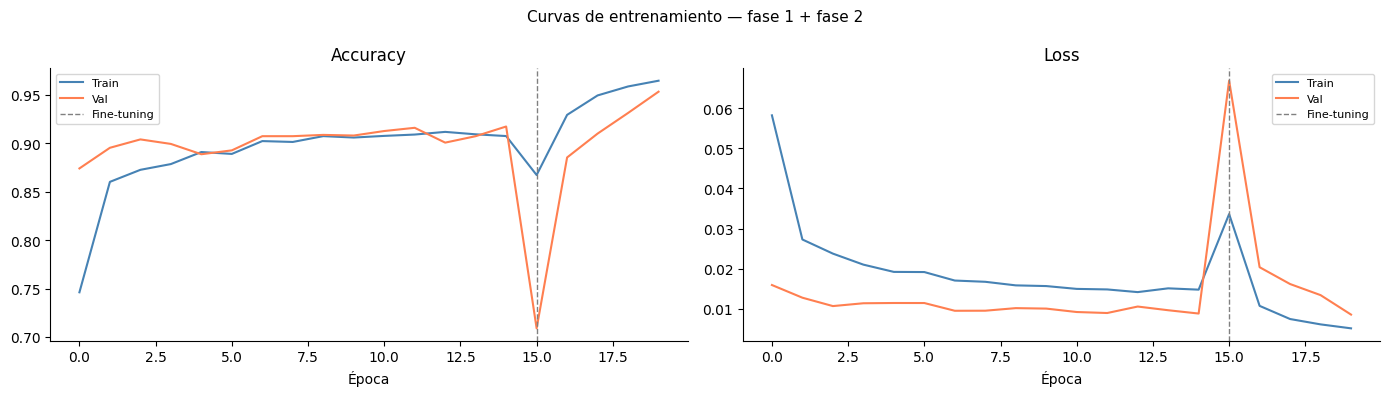

In [20]:
def plot_history(h1, h2):
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    vloss= h1.history['val_loss'] + h2.history['val_loss']
    sep  = len(h1.history['accuracy'])  # época donde empieza fase 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, train_m, val_m, title in zip(
        axes,
        [acc, loss], [val, vloss],
        ['Accuracy', 'Loss']
    ):
        ax.plot(train_m, label='Train', color='steelblue')
        ax.plot(val_m,   label='Val',   color='coral')
        ax.axvline(sep, color='gray', linestyle='--', linewidth=1, label='Fine-tuning')
        ax.set_title(title)
        ax.set_xlabel('Época')
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)

    plt.suptitle('Curvas de entrenamiento — fase 1 + fase 2', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, history2)

## 11. Evaluación en test — métricas completas

REPORTE DE CLASIFICACION - TEST SET (KERAS FLOAT32)
                precision    recall  f1-score   support

  early_blight     0.9975    0.9038    0.9484       447
       healthy     0.9172    0.9779    0.9466       136
   late_blight     0.9377    0.9664    0.9518       327
leafroll_virus     1.0000    0.9444    0.9714        90
  mosaic_virus     0.8609    1.0000    0.9252        99
      nematode     0.9846    1.0000    0.9922        64
          pest     0.8227    0.9134    0.8657       127
   z_no_potato     0.9856    0.9716    0.9785       211

      accuracy                         0.9474      1501
     macro avg     0.9383    0.9597    0.9475      1501
  weighted avg     0.9513    0.9474    0.9479      1501



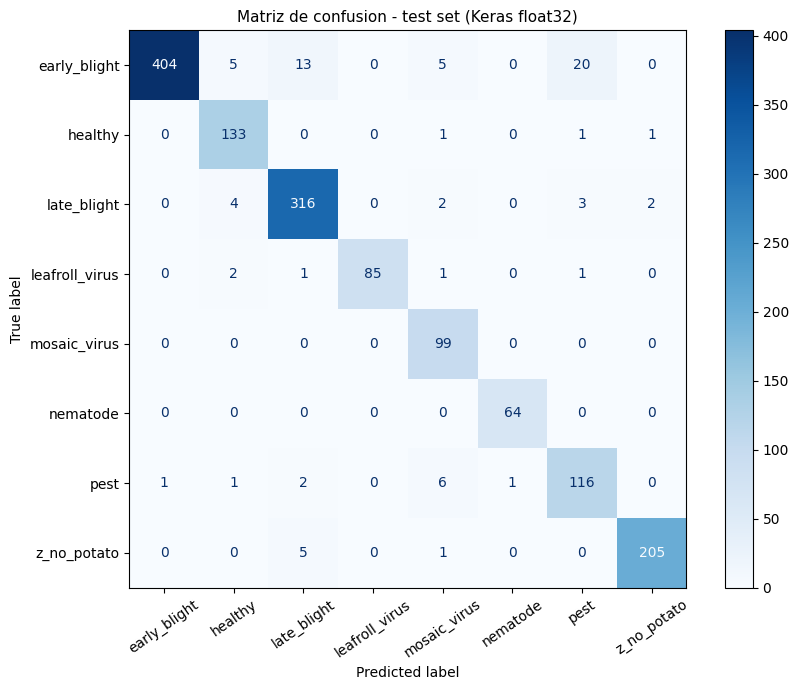


Resumen de auditoria por imagen:
  Total evaluadas: 1501
  Aciertos       : 1422
  Errores        : 79

Primeras 20 predicciones:


,filename,path,true_label,pred_label,confidence,correct
0,Late_Blight (202).JPG,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,late_blight,0.971690,True
1,ps1 (5).jpg,/kaggle/input/datasets/kevinvichicela/datasert...,z_no_potato,z_no_potato,0.999999,True
2,DSC_0477.JPG,/kaggle/input/datasets/kevinvichicela/datasert...,leafroll_virus,leafroll_virus,0.995998,True
3,IMG_0389.JPG,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,late_blight,0.999730,True
4,IMG_0285.JPG,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,pest,0.615290,False
5,IMG_20230816_140606~2.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,pest,pest,0.962563,True
6,IMG_20210811_142103.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,leafroll_virus,leafroll_virus,0.999998,True
7,Late_Blight (45).JPG,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,late_blight,0.988733,True
8,68841.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,late_blight,0.999517,True
9,IMG_20230816_123551.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,early_blight,0.655848,True



Primeros 30 errores (si existen):


,filename,path,true_label,pred_label,confidence,correct
0,IMG_0274.JPG,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,mosaic_virus,0.997317,False
1,3d8e1f90-be34-4da7-b124-a98eddb346d1___RS_Erly...,/kaggle/input/datasets/kevinvichicela/datasert...,z_no_potato,late_blight,0.996355,False
2,1692334247335.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,pest,mosaic_virus,0.991313,False
3,IMG_20230816_075617.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,pest,0.987038,False
4,67522.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,late_blight,0.978664,False
5,20230712_154041_aug0.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,pest,mosaic_virus,0.975254,False
6,68966.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,z_no_potato,0.970431,False
7,IMG_9382.JPG,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,late_blight,0.969895,False
8,69255.jpg,/kaggle/input/datasets/kevinvichicela/datasert...,late_blight,z_no_potato,0.969060,False
9,IMG_20230816_091248 (1).jpg,/kaggle/input/datasets/kevinvichicela/datasert...,early_blight,pest,0.965800,False



CSV exportados:
  - /kaggle/working/keras_test_predictions.csv
  - /kaggle/working/keras_test_errors.csv


In [21]:
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Auditoria detallada por imagen para saber en cuales falla el modelo
records_eval = []
y_true, y_pred = [], []

for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _ = load_and_preprocess(path, true_idx, augment=False)
    probs = model.predict(np.expand_dims(arr, 0), verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]
    conf = float(probs[pred_idx])

    y_true.append(true_idx)
    y_pred.append(pred_idx)

    records_eval.append({
        'filename': Path(path).name,
        'path': path,
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': conf,
        'correct': pred_label == true_label,
    })

print('=' * 60)
print('REPORTE DE CLASIFICACION - TEST SET (KERAS FLOAT32)')
print('=' * 60)
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
ax.set_title('Matriz de confusion - test set (Keras float32)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla completa de predicciones y subset de errores
df_test_predictions = pd.DataFrame(records_eval)
df_test_errors = (
    df_test_predictions[~df_test_predictions['correct']]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)

print('\nResumen de auditoria por imagen:')
print(f"  Total evaluadas: {len(df_test_predictions)}")
print(f"  Aciertos       : {int(df_test_predictions['correct'].sum())}")
print(f"  Errores        : {len(df_test_errors)}")

print('\nPrimeras 20 predicciones:')
display(df_test_predictions.head(20))

print('\nPrimeros 30 errores (si existen):')
display(df_test_errors.head(30))

pred_csv_path = OUTPUT_DIR / 'keras_test_predictions.csv'
err_csv_path = OUTPUT_DIR / 'keras_test_errors.csv'
df_test_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
df_test_errors.to_csv(err_csv_path, index=False, encoding='utf-8-sig')

print('\nCSV exportados:')
print(f'  - {pred_csv_path}')
print(f'  - {err_csv_path}')

## 12. Exportación a TFLite (int8)
Cuantización post-entrenamiento. Reduce el modelo a ~14–25 MB para el APK.

In [22]:
# Dataset representativo para calibración int8 (100 imágenes de val)
def representative_dataset():
    count = 0
    for img_batch, _ in val_ds:
        for img in img_batch:
            yield [tf.expand_dims(img, 0)]
            count += 1
            if count >= 100:
                return

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

# Guardar el modelo base .tflite
tflite_model = converter.convert()
tflite_path = OUTPUT_DIR / 'potato_classifier.tflite'
tflite_path.write_bytes(tflite_model)

# Guardar las etiquetas aparte (ya que no se pueden incrustar directamente aquí)
labels_path = OUTPUT_DIR / 'labels.txt'
with open(labels_path, 'w') as f:
    f.write('\n'.join(classes))

size_mb = tflite_path.stat().st_size / 1_048_576
print(f'Modelo TFLite guardado: {tflite_path}')
print(f'Etiquetas guardadas en: {labels_path}')
print(f'Tamaño del modelo: {size_mb:.2f} MB')



INFO:tensorflow:Assets written to: /tmp/tmpqexurpi9/assets


INFO:tensorflow:Assets written to: /tmp/tmpqexurpi9/assets


Saved artifact at '/tmp/tmpqexurpi9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  134280578247632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578246480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578248976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578248208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578247824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578246288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578249168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578249936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578249552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134280578248400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1342805782

W0000 00:00:1779151900.188407      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779151900.188458      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1779151900.335492      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Modelo TFLite guardado: /kaggle/working/potato_classifier.tflite
Etiquetas guardadas en: /kaggle/working/labels.txt
Tamaño del modelo: 2.59 MB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [23]:
from sklearn.metrics import accuracy_score

# Cargar el modelo TFLite exportado
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale, in_zero_point = input_details['quantization']
out_scale, out_zero_point = output_details['quantization']

print('Entrada TFLite:', input_details['dtype'], input_details['shape'], input_details['quantization'])
print('Salida TFLite :', output_details['dtype'], output_details['shape'], output_details['quantization'])


def run_tflite_int8_single(img_float_m1_1):
    """
    img_float_m1_1: np.ndarray [H,W,3] normalizada en [-1, 1]
    Retorna probs float32 des-cuantizadas.
    """
    x = np.expand_dims(img_float_m1_1, axis=0).astype(np.float32)

    # Cuantizar entrada float -> uint8 usando parametros del tensor de entrada
    if in_scale > 0:
        x_q = np.round(x / in_scale + in_zero_point)
    else:
        x_q = x
    x_q = np.clip(x_q, 0, 255).astype(np.uint8)

    interpreter.set_tensor(input_details['index'], x_q)
    interpreter.invoke()
    y_q = interpreter.get_tensor(output_details['index'])

    # Des-cuantizar salida uint8 -> float
    if out_scale > 0:
        y = (y_q.astype(np.float32) - out_zero_point) * out_scale
    else:
        y = y_q.astype(np.float32)

    return y[0]


# Evaluacion del TFLite en el mismo test set
y_true_tflite, y_pred_tflite = [], []
for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _ = load_and_preprocess(path, true_idx, augment=False)
    probs = run_tflite_int8_single(arr)
    pred_idx = int(np.argmax(probs))

    y_true_tflite.append(true_idx)
    y_pred_tflite.append(pred_idx)

acc_tflite = accuracy_score(y_true_tflite, y_pred_tflite)

# Accuracy Keras float ya calculada antes (si no existe, la recalculamos rapido)
if 'y_true' in globals() and 'y_pred' in globals() and len(y_true) == len(y_pred):
    acc_keras = accuracy_score(y_true, y_pred)
else:
    y_true_keras, y_pred_keras = [], []
    for batch_imgs, batch_labels in test_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred_keras.extend(np.argmax(preds, axis=1))
        y_true_keras.extend(batch_labels.numpy())
    acc_keras = accuracy_score(y_true_keras, y_pred_keras)

print('\n' + '=' * 65)
print('COMPARACION DE ACCURACY EN TEST')
print('=' * 65)
print(f'Keras (float32): {acc_keras:.4f}')
print(f'TFLite (int8) : {acc_tflite:.4f}')
print(f'Delta (int8 - float): {acc_tflite - acc_keras:+.4f}')
print('=' * 65)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Entrada TFLite: <class 'numpy.uint8'> [  1 224 224   3] (0.007843137718737125, 127)
Salida TFLite : <class 'numpy.uint8'> [1 8] (0.00390625, 0)

COMPARACION DE ACCURACY EN TEST
Keras (float32): 0.9474
TFLite (int8) : 0.9340
Delta (int8 - float): -0.0133


REPORTE TFLITE (INT8) - LISTO PARA TESIS

Metricas globales:


,metrica,valor
0,accuracy,0.934044
1,macro avg precision,0.925234
2,macro avg recall,0.949070
3,macro avg f1-score,0.934721
4,weighted avg precision,0.940905
5,weighted avg recall,0.934044
6,weighted avg f1-score,0.935088



Metricas por clase:


,clase,precision,recall,f1-score,support
0,early_blight,1.000000,0.876957,0.934446,447
1,healthy,0.902778,0.955882,0.928571,136
2,late_blight,0.929204,0.963303,0.945946,327
3,leafroll_virus,1.000000,0.944444,0.971429,90
4,mosaic_virus,0.831933,1.000000,0.908257,99
5,nematode,1.000000,0.984375,0.992126,64
6,pest,0.766667,0.905512,0.830325,127
7,z_no_potato,0.971292,0.962085,0.966667,211


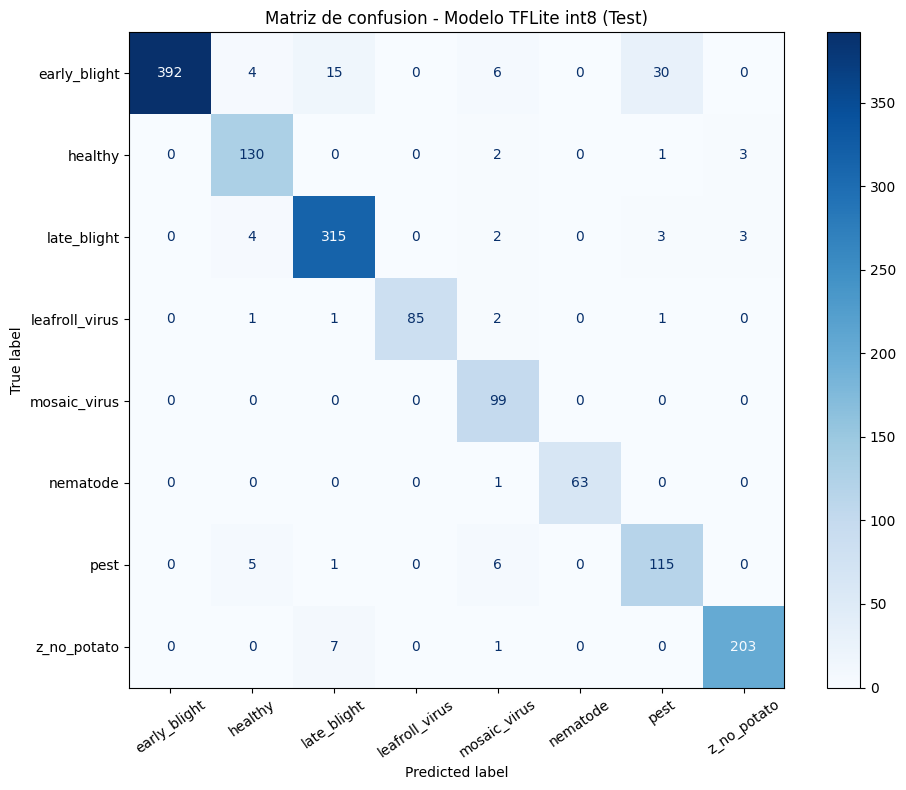


Archivos exportados:
  - /kaggle/working/tflite_report_per_class.csv
  - /kaggle/working/tflite_report_summary.csv
  - /kaggle/working/confusion_matrix_tflite.png


In [24]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1) Reporte de clasificacion
# -----------------------------
report_dict = classification_report(
    y_true_tflite,
    y_pred_tflite,
    target_names=classes,
    digits=4,
    output_dict=True,
    zero_division=0
)

# Tabla por clase
rows = []
for cls in classes:
    rows.append({
        'clase': cls,
        'precision': report_dict[cls]['precision'],
        'recall': report_dict[cls]['recall'],
        'f1-score': report_dict[cls]['f1-score'],
        'support': int(report_dict[cls]['support'])
    })

df_cls = pd.DataFrame(rows)

# Tabla de resumen
df_summary = pd.DataFrame([
    {
        'metrica': 'accuracy',
        'valor': float(report_dict['accuracy'])
    },
    {
        'metrica': 'macro avg precision',
        'valor': float(report_dict['macro avg']['precision'])
    },
    {
        'metrica': 'macro avg recall',
        'valor': float(report_dict['macro avg']['recall'])
    },
    {
        'metrica': 'macro avg f1-score',
        'valor': float(report_dict['macro avg']['f1-score'])
    },
    {
        'metrica': 'weighted avg precision',
        'valor': float(report_dict['weighted avg']['precision'])
    },
    {
        'metrica': 'weighted avg recall',
        'valor': float(report_dict['weighted avg']['recall'])
    },
    {
        'metrica': 'weighted avg f1-score',
        'valor': float(report_dict['weighted avg']['f1-score'])
    }
])

print('=' * 70)
print('REPORTE TFLITE (INT8) - LISTO PARA TESIS')
print('=' * 70)
print('\nMetricas globales:')
display(df_summary)
print('\nMetricas por clase:')
display(df_cls)

# -----------------------------
# 2) Matriz de confusion
# -----------------------------
cm_tflite = confusion_matrix(y_true_tflite, y_pred_tflite)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tflite, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
ax.set_title('Matriz de confusion - Modelo TFLite int8 (Test)', fontsize=12)
plt.tight_layout()

cm_img_path = OUTPUT_DIR / 'confusion_matrix_tflite.png'
plt.savefig(cm_img_path, dpi=160, bbox_inches='tight')
plt.show()

# -----------------------------
# 3) Guardar tablas para tesis
# -----------------------------
cls_csv_path = OUTPUT_DIR / 'tflite_report_per_class.csv'
sum_csv_path = OUTPUT_DIR / 'tflite_report_summary.csv'

# Redondeo para reporte
df_cls_out = df_cls.copy()
df_cls_out[['precision', 'recall', 'f1-score']] = df_cls_out[['precision', 'recall', 'f1-score']].round(4)
df_summary_out = df_summary.copy()
df_summary_out['valor'] = df_summary_out['valor'].round(4)

df_cls_out.to_csv(cls_csv_path, index=False, encoding='utf-8-sig')
df_summary_out.to_csv(sum_csv_path, index=False, encoding='utf-8-sig')

print('\nArchivos exportados:')
print(f'  - {cls_csv_path}')
print(f'  - {sum_csv_path}')
print(f'  - {cm_img_path}')

## 13. Generación de Grad-CAM estáticos por clase
Se calcula el mapa de activación de la última capa conv de MobileNetV2 para una imagen
representativa de cada clase. Estos mapas se empaquetan en el APK como recursos estáticos —
latencia extra en inferencia: 0 ms.

In [25]:
import matplotlib as mpl
import numpy as np
import matplotlib as mpl
from PIL import Image

last_conv_layer = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    raise ValueError("No se encontró ninguna capa Conv2D en base_model")

print("Usando capa:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

# Submodelo interno: base_model.input → (base_model.output, conv_outputs)
# Evita el problema de Graph disconnected al no cruzar el límite base→model
base_grad_model = tf.keras.Model(
    inputs=base_model.inputs,
    outputs=[base_model.output, last_conv_layer.output]
)

# Capas superiores del modelo principal (fuera de la base)
gap_layer     = model.get_layer('global_average_pooling2d')
dropout_layer = model.get_layer('dropout')
dense_layer   = model.get_layer('dense')

# Verificación
print("\nVerificación base_grad_model:")
print("  Input shape :", base_grad_model.input_shape)
print("  Output[0]   :", base_grad_model.output[0].shape, "← base output")
print("  Output[1]   :", base_grad_model.output[1].shape, "← conv activations")


def compute_gradcam(img_array: np.ndarray, class_idx: int) -> np.ndarray:
    """Retorna heatmap normalizado [0,1] del tamaño IMG_SIZE×IMG_SIZE."""
    img_tensor = tf.cast(tf.expand_dims(img_array, 0), tf.float32)

    with tf.GradientTape() as tape:
        base_out, conv_outputs = base_grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        # Reconstruir el forward pass de las capas superiores
        x      = gap_layer(base_out)
        x      = dropout_layer(x, training=False)
        preds  = dense_layer(x)
        class_score = preds[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError(
            f"Gradientes None para clase {class_idx}. "
            "Verificar conexión de base_grad_model."
        )

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1)
    cam = tf.maximum(cam, 0)
    cam_np = cam.numpy()
    cam_max = np.max(cam_np)
    cam_min = np.min(cam_np)

    
    if (cam_max - cam_min) > 1e-8:
      
        cam_np = (cam_np - cam_min) / (cam_max - cam_min)
    else:
        
        cam_np = np.zeros_like(cam_np)

    cam_img = Image.fromarray((cam_np * 255).astype(np.uint8))
    cam_img = cam_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    
    return np.array(cam_img) / 255.0


def overlay_heatmap(original_arr: np.ndarray,
                    heatmap: np.ndarray,
                    color_alpha: float = 0.6) -> np.ndarray: # CAMBIADO DE alpha A color_alpha
    """Superpone el heatmap coloreado (jet) sobre la imagen original."""

    orig_uint8 = ((original_arr + 1.0) * 127.5).astype(np.uint8)
    orig_img = Image.fromarray(orig_uint8).convert("RGBA")
    
    colormap = mpl.colormaps['jet']
    heatmap_rgb = (colormap(heatmap)[:, :, :3] * 255).astype(np.uint8)
    
    dynamic_alpha = np.power(heatmap, 1.5) 
    
    dynamic_alpha = dynamic_alpha * color_alpha
    
    alpha_mask_uint8 = (dynamic_alpha * 255).astype(np.uint8)
    
    rgba_heatmap_np = np.dstack((heatmap_rgb, alpha_mask_uint8))
    heatmap_img = Image.fromarray(rgba_heatmap_np, "RGBA")
    
    blended_img = Image.alpha_composite(orig_img, heatmap_img)
    
    return np.array(blended_img.convert("RGB"))

print('\nFunciones Grad-CAM listas.')

Usando capa: Conv_1
Output shape: (None, 7, 7, 1280)

Verificación base_grad_model:
  Input shape : (None, 224, 224, 3)
  Output[0]   : (None, 7, 7, 1280) ← base output
  Output[1]   : (None, 7, 7, 1280) ← conv activations

Funciones Grad-CAM listas.


In [26]:
# Buscar las TOP 3 imágenes de test con mayor confianza por clase
TOP_N = 3
gradcam_dir = OUTPUT_DIR / 'gradcam_static'
gradcam_dir.mkdir(exist_ok=True)

# Ahora guardamos una lista de resultados por clase, no solo uno
top_per_class = {i: [] for i in range(NUM_CLASSES)}

print("Analizando imágenes y recolectando candidatos...")
for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _   = load_and_preprocess(path, true_idx, augment=False)
    preds    = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    pred_idx = np.argmax(preds)
    conf     = float(preds[pred_idx])
    
    # Solo candidatos correctamente clasificados y evitando la saturación del 1.0 absoluto
    if pred_idx == true_idx and conf < 0.99:
        top_per_class[true_idx].append({'conf': conf, 'path': path, 'arr': arr})

# Generar y guardar los Grad-CAM en la carpeta
print(f"\nGenerando y guardando las mejores {TOP_N} imágenes por clase...")
for cls_idx, cls_name in enumerate(classes):
    
    # Ordenamos todas las imágenes de esta clase de mayor a menor confianza
    # y nos quedamos solo con la cantidad definida en TOP_N
    candidates = sorted(top_per_class[cls_idx], key=lambda x: x['conf'], reverse=True)[:TOP_N]
    
    if not candidates:
        print(f'  AVISO: no se encontraron imágenes para {cls_name}')
        continue
        
    print(f"  -> Guardando {len(candidates)} opciones para {cls_name}...")
    
    for rank, info in enumerate(candidates):
        arr     = info['arr']
        heatmap = compute_gradcam(arr, cls_idx)
        overlay = overlay_heatmap(arr, heatmap)

        # Guardar directamente la imagen procesada con un nombre descriptivo
        # Ejemplo: gradcam_late_blight_top1_conf0.985.jpg
        filename = f'gradcam_{cls_name}_top{rank+1}_conf{info["conf"]:.3f}.jpg'
        out_path = gradcam_dir / filename
        Image.fromarray(overlay).save(str(out_path), quality=90)

print(f'\n¡Proceso terminado!')
print(f'Ve al panel derecho de Kaggle, entra a la carpeta: {gradcam_dir}')
print('Ahí tendrás todas las imágenes listas para descargar y elegir la mejor.')

Analizando imágenes y recolectando candidatos...

Generando y guardando las mejores 3 imágenes por clase...
  -> Guardando 3 opciones para early_blight...
  -> Guardando 3 opciones para healthy...
  -> Guardando 3 opciones para late_blight...
  -> Guardando 3 opciones para leafroll_virus...
  -> Guardando 1 opciones para mosaic_virus...
  -> Guardando 3 opciones para nematode...
  -> Guardando 3 opciones para pest...
  -> Guardando 3 opciones para z_no_potato...

¡Proceso terminado!
Ve al panel derecho de Kaggle, entra a la carpeta: /kaggle/working/gradcam_static
Ahí tendrás todas las imágenes listas para descargar y elegir la mejor.


## 14. Resumen de archivos generados

In [27]:
print('=' * 55)
print('ARCHIVOS GENERADOS')
print('=' * 55)

outputs = [
    OUTPUT_DIR / 'potato_classifier.tflite',
    OUTPUT_DIR / 'best_phase2.keras',
    OUTPUT_DIR / 'training_curves.png',
    OUTPUT_DIR / 'confusion_matrix.png',
    OUTPUT_DIR / 'gradcam_all_classes.png',
]
outputs += list(gradcam_dir.glob('*.jpg'))

for f in outputs:
    if Path(f).exists():
        size = Path(f).stat().st_size / 1024
        print(f'  {Path(f).name:<40} {size:>8.1f} KB')
    else:
        print(f'  {Path(f).name:<40}  NO ENCONTRADO')

print('=' * 55)
print()
print('Para Android necesitas:')
print('  1. potato_classifier.tflite  → /assets/ en el proyecto Android')
print('  2. gradcam_*.jpg             → /res/drawable/ en el proyecto Android')
print()
print('class_to_idx (para el clasificador en Kotlin):')
for cls, idx in class_to_idx.items():
    print(f'  {idx}: "{cls}"')

ARCHIVOS GENERADOS
  potato_classifier.tflite                   2656.1 KB
  best_phase2.keras                         24095.5 KB
  training_curves.png                          96.0 KB
  confusion_matrix.png                         97.0 KB
  gradcam_all_classes.png                   NO ENCONTRADO
  gradcam_z_no_potato_top3_conf0.974.jpg        7.8 KB
  gradcam_nematode_top1_conf0.989.jpg          12.6 KB
  gradcam_nematode_top2_conf0.989.jpg          12.8 KB
  gradcam_early_blight_top2_conf0.990.jpg      16.0 KB
  gradcam_late_blight_top3_conf0.990.jpg       16.3 KB
  gradcam_early_blight_top1_conf0.990.jpg      15.4 KB
  gradcam_leafroll_virus_top1_conf0.988.jpg      7.1 KB
  gradcam_leafroll_virus_top3_conf0.984.jpg      6.7 KB
  gradcam_healthy_top2_conf0.989.jpg           17.0 KB
  gradcam_late_blight_top1_conf0.990.jpg       14.9 KB
  gradcam_z_no_potato_top2_conf0.975.jpg       16.1 KB
  gradcam_pest_top2_conf0.989.jpg              15.0 KB
  gradcam_healthy_top1_conf0.989.jpg     